In [1]:
# ============================================================
# BLOQUE 2: Importación de librerías
# ============================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import os

# Configuración de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

In [2]:
# ============================================================
# BLOQUE 3: Carga de datasets
# ============================================================

# --- Tweets ---
tweets_raw = pd.read_csv("tweets_gobierno_economia.csv")

# --- ICC ---
icc_raw = pd.read_csv(
    "evolucion_de_la_confianza_del_consumidor_desde_2004.csv",
    sep=";"
)

print("=== DIMENSIONES INICIALES ===")
print(f"Tweets: {tweets_raw.shape[0]} filas × {tweets_raw.shape[1]} columnas")
print(f"ICC:    {icc_raw.shape[0]} filas × {icc_raw.shape[1]} columnas")

=== DIMENSIONES INICIALES ===
Tweets: 11198 filas × 11 columnas
ICC:    267 filas × 3 columnas


In [3]:
# ============================================================
# BLOQUE 4: Exploración inicial de tweets
# ============================================================

print("=== PRIMERAS FILAS ===")
display(tweets_raw.head())

print("\n=== COLUMNAS Y TIPOS INICIALES ===")
display(tweets_raw.dtypes.to_frame(name="Tipo"))

print("\n=== VALORES NULOS POR COLUMNA ===")
display(tweets_raw.isnull().sum().to_frame(name="Nulos"))

print(f"\n=== DUPLICADOS (por id) ===")
n_dup_id = tweets_raw.duplicated(subset=["id"]).sum()
print(f"Filas con id duplicado: {n_dup_id}")

print(f"\nDuplicados exactos (todas las columnas): {tweets_raw.duplicated().sum()}")

print("\n=== CUENTAS PRESENTES ===")
display(tweets_raw["username"].value_counts().to_frame(name="Tweets"))

=== PRIMERAS FILAS ===


,id,fecha,username,contenido,hashtags,tipo,url_media,comentarios,retweets,likes,views
0,2047346501915963634,"Apr 23, 2026 · 4:06 PM UTC",@_minecogob,El sexto desembolso del Plan de Recuperación asciende a unos 7.000M€ (5.600 ...,NaN,Texto simple,NaN,0,30,53,"1,163"
1,2047344028933320813,"Apr 23, 2026 · 3:57 PM UTC",@_minecogob,Gracias a 10.500M€ en préstamos del Plan de Recuperación movilizaremos unos ...,NaN,Texto simple,NaN,11,63,123,"2,778"
2,2047314800384823490,"Apr 23, 2026 · 2:01 PM UTC",@_minecogob,El VP1 @carlos_cuerpo comparece en el @Congreso_Es para dar cuenta de los av...,NaN,Imagen,https://nitter.net/pic/orig/media%2FHGlw8NnWkAA03cg.jpg,2,18,34,727
3,2047231369424588986,"Apr 23, 2026 · 8:29 AM UTC",@carlos_cuerpo,Hablar en el @Congreso_Es de los problemas que realmente preocupan a los ciu...,NaN,Texto simple,NaN,106,414,"1,115","13,674"
4,2047204712961724433,"Apr 23, 2026 · 6:43 AM UTC",@_minecogob,El VP1 @carlos_cuerpo es entrevistado en @LasMananas_rne @rne.\n\n⏰A partir ...,NaN,Imagen,https://nitter.net/pic/orig/media%2FHGkh1iuXkAAUhLa.jpg,0,0,1,207



=== COLUMNAS Y TIPOS INICIALES ===


,Tipo
id,int64
fecha,str
username,str
contenido,str
hashtags,str
tipo,str
url_media,str
comentarios,str
retweets,str
likes,str



=== VALORES NULOS POR COLUMNA ===


,Nulos
id,0
fecha,0
username,0
contenido,8
hashtags,2646
tipo,0
url_media,5387
comentarios,0
retweets,0
likes,0



=== DUPLICADOS (por id) ===
Filas con id duplicado: 65

Duplicados exactos (todas las columnas): 63

=== CUENTAS PRESENTES ===


,Tweets
username,
@_minecogob,6391
@NadiaCalvino,1422
@desdelamoncloa,873
@carlos_cuerpo,254
@SEDIAgob,213
...,...
@AmChamSpain,1
@EUScienceInnov,1
@HablamosdEuropa,1


In [4]:
# ============================================================
# BLOQUE 5: Exploración inicial del ICC
# ============================================================

print("=== PRIMERAS FILAS ===")
display(icc_raw.head())

print("\n=== COLUMNAS Y TIPOS INICIALES ===")
display(icc_raw.dtypes.to_frame(name="Tipo"))

print("\n=== VALORES NULOS POR COLUMNA ===")
display(icc_raw.isnull().sum().to_frame(name="Nulos"))

print(f"\n=== DIMENSIONES ===")
print(f"Observaciones: {icc_raw.shape[0]}")
print(f"Rango de años declarados: {icc_raw['Año'].min()} – {icc_raw['Año'].max()}")

=== PRIMERAS FILAS ===


,Año,Periodo,Confianza del consumidor
0,2004,Septiembre,"96,69"
1,2004,Octubre,"90,64"
2,2004,Noviembre,"90,05"
3,2004,Diciembre,"92,11"
4,2005,Enero,"98,03"



=== COLUMNAS Y TIPOS INICIALES ===


,Tipo
Año,str
Periodo,str
Confianza del consumidor,str



=== VALORES NULOS POR COLUMNA ===


,Nulos
Año,4
Periodo,14
Confianza del consumidor,14



=== DIMENSIONES ===
Observaciones: 267
Rango de años declarados: 2004 – Url:"https://www.epdata.es/evolucion-confianza-consumidor-2004/a66415fd-68e0-4778-baf0-36799e09f9d7/espana/106"


In [5]:
# ============================================================
# BLOQUE 6: Validación de estructura
# ============================================================

# --- Tweets: columnas obligatorias ---
cols_requeridas_tweets = ["id", "fecha", "username", "contenido",
                          "comentarios", "retweets", "likes", "views"]
cols_presentes = [c for c in cols_requeridas_tweets if c in tweets_raw.columns]
cols_ausentes  = [c for c in cols_requeridas_tweets if c not in tweets_raw.columns]

print("Columnas requeridas presentes:", cols_presentes)
print("Columnas requeridas AUSENTES: ", cols_ausentes if cols_ausentes else "Ninguna")

# --- ICC: columnas obligatorias ---
cols_requeridas_icc = ["Año", "Periodo", "Confianza del consumidor"]
cols_presentes_icc = [c for c in cols_requeridas_icc if c in icc_raw.columns]
cols_ausentes_icc  = [c for c in cols_requeridas_icc if c not in icc_raw.columns]

print("\nColumnas ICC requeridas presentes:", cols_presentes_icc)
print("Columnas ICC AUSENTES:            ", cols_ausentes_icc if cols_ausentes_icc else "Ninguna")

Columnas requeridas presentes: ['id', 'fecha', 'username', 'contenido', 'comentarios', 'retweets', 'likes', 'views']
Columnas requeridas AUSENTES:  Ninguna

Columnas ICC requeridas presentes: ['Año', 'Periodo', 'Confianza del consumidor']
Columnas ICC AUSENTES:             Ninguna


In [6]:
# ============================================================
# BLOQUE 7: Normalización de fechas
# ============================================================

# --- Tweets ---
tweets = tweets_raw.copy()

# La columna 'fecha' tiene formato: "Apr 23, 2026 · 4:06 PM UTC"
tweets["fecha_limpia"] = (
    tweets["fecha"]
    .astype(str)
    .str.replace(" · ", " ", regex=False)
    .str.replace(" UTC", "", regex=False)
)

tweets["fecha_dt"] = pd.to_datetime(
    tweets["fecha_limpia"],
    format="%b %d, %Y %I:%M %p",
    errors="coerce"
)

n_nulos_fecha = tweets["fecha_dt"].isna().sum()
print(f"Fechas no parseadas: {n_nulos_fecha}")
print(f"Fecha mínima del corpus: {tweets['fecha_dt'].min()}")
print(f"Fecha máxima del corpus: {tweets['fecha_dt'].max()}")

# Columna de mes (primer día del mes)
tweets["mes"] = tweets["fecha_dt"].dt.to_period("M").dt.to_timestamp()

# --- ICC ---
icc = icc_raw.copy()

# Eliminar filas donde Año no sea numérico
icc = icc[pd.to_numeric(icc["Año"], errors="coerce").notna()].copy()
icc["Año"] = icc["Año"].astype(int)

# Mapa de meses en español
meses_es = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
icc["mes_num"] = icc["Periodo"].map(meses_es)

icc["fecha_mes"] = pd.to_datetime(
    dict(year=icc["Año"], month=icc["mes_num"], day=1)
)

# Normalizar valor ICC
icc["ICC"] = (
    icc["Confianza del consumidor"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

icc = icc[["fecha_mes", "ICC"]].sort_values("fecha_mes").reset_index(drop=True)

print(f"\nICC — Rango: {icc['fecha_mes'].min().date()} → {icc['fecha_mes'].max().date()}")
print(f"Observaciones totales ICC: {icc.shape[0]}")

Fechas no parseadas: 0
Fecha mínima del corpus: 2012-02-17 12:46:00
Fecha máxima del corpus: 2026-04-23 16:06:00

ICC — Rango: 2004-09-01 → 2026-01-01
Observaciones totales ICC: 253


In [7]:
# ============================================================
# BLOQUE 8: Filtrado temporal 2020–2025
# ============================================================

FECHA_INICIO = pd.Timestamp("2020-01-01")
FECHA_FIN    = pd.Timestamp("2025-12-31")

# Filtro de tweets
mask_periodo = (tweets["fecha_dt"] >= FECHA_INICIO) & (tweets["fecha_dt"] <= FECHA_FIN)
tweets_periodo = tweets[mask_periodo].copy()

print(f"Tweets en el corpus completo:        {tweets.shape[0]}")
print(f"Tweets en periodo 2020–2025:         {tweets_periodo.shape[0]}")
print(f"Proporción conservada:               {tweets_periodo.shape[0]/tweets.shape[0]*100:.1f}%")

# Filtro ICC
mask_icc = (icc["fecha_mes"] >= FECHA_INICIO) & (icc["fecha_mes"] <= FECHA_FIN)
icc_periodo = icc[mask_icc].copy().reset_index(drop=True)

print(f"\nObservaciones ICC 2020–2025: {icc_periodo.shape[0]}")
print(f"Primer dato: {icc_periodo['fecha_mes'].min().date()}")
print(f"Último dato: {icc_periodo['fecha_mes'].max().date()}")

Tweets en el corpus completo:        11198
Tweets en periodo 2020–2025:         7319
Proporción conservada:               65.4%

Observaciones ICC 2020–2025: 68
Primer dato: 2020-01-01
Último dato: 2025-12-01


In [8]:
# ============================================================
# BLOQUE 9: Corpus principal — @_minecogob
# ============================================================

CUENTA_PRINCIPAL = "@_minecogob"

tweets_minecocom = tweets_periodo[
    tweets_periodo["username"] == CUENTA_PRINCIPAL
].copy().reset_index(drop=True)

print(f"Tweets de {CUENTA_PRINCIPAL} en 2020–2025: {tweets_minecocom.shape[0]}")

# Distribución anual
print("\n--- Distribución anual ---")
anual = tweets_minecocom.groupby(tweets_minecocom["fecha_dt"].dt.year).size()
display(anual.rename("Tweets").to_frame())

# Cobertura mensual
print("\n--- Meses cubiertos (de 72 posibles) ---")
meses_cubiertos = tweets_minecocom["mes"].nunique()
print(f"Meses con al menos 1 tweet: {meses_cubiertos}")
print(f"Meses sin tweets: {72 - meses_cubiertos}")

# Tweets por mes
mensual_minecocom = tweets_minecocom.groupby("mes").size().rename("n_tweets")
meses_sin_tweets = mensual_minecocom[mensual_minecocom == 0]
print(f"\nMeses con 0 tweets: {meses_sin_tweets.shape[0]}")

Tweets de @_minecogob en 2020–2025: 4606

--- Distribución anual ---


,Tweets
fecha_dt,
2020,699
2021,1079
2022,1213
2023,858
2024,444
2025,313



--- Meses cubiertos (de 72 posibles) ---
Meses con al menos 1 tweet: 72
Meses sin tweets: 0

Meses con 0 tweets: 0


In [9]:
# ============================================================
# BLOQUE 10: Corpus complementario — @SE_Comercio
# ============================================================

CUENTA_COMPLEMENTARIA = "@SE_Comercio"

# Verificar si existe en el dataset
if CUENTA_COMPLEMENTARIA in tweets_periodo["username"].values:
    tweets_comercio = tweets_periodo[
        tweets_periodo["username"] == CUENTA_COMPLEMENTARIA
    ].copy().reset_index(drop=True)

    print(f"Tweets de {CUENTA_COMPLEMENTARIA} en 2020–2025: {tweets_comercio.shape[0]}")

    print("\n--- Distribución anual ---")
    anual_com = tweets_comercio.groupby(tweets_comercio["fecha_dt"].dt.year).size()
    display(anual_com.rename("Tweets").to_frame())

    print(f"\n--- Meses cubiertos: {tweets_comercio['mes'].nunique()} de 72 posibles ---")
else:
    tweets_comercio = pd.DataFrame(columns=tweets_periodo.columns)
    print(f"AVISO: {CUENTA_COMPLEMENTARIA} no encontrada en el dataset.")
    print("Se crea DataFrame vacío para uso posterior.")

Tweets de @SE_Comercio en 2020–2025: 38

--- Distribución anual ---


,Tweets
fecha_dt,
2023,7
2024,20
2025,11



--- Meses cubiertos: 18 de 72 posibles ---


In [10]:
# ============================================================
# BLOQUE 11: Valores nulos — corpus principal
# ============================================================

print("=== NULOS EN TWEETS @_minecogob 2020–2025 ===")
nulos = tweets_minecocom.isnull().sum()
pct_nulos = (nulos / tweets_minecocom.shape[0] * 100).round(2)
tabla_nulos = pd.DataFrame({"Nulos": nulos, "% sobre total": pct_nulos})
display(tabla_nulos[tabla_nulos["Nulos"] > 0] if (tabla_nulos["Nulos"] > 0).any()
        else tabla_nulos)

# Contenido vacío (no nulo pero cadena vacía)
n_contenido_vacio = (tweets_minecocom["contenido"].astype(str).str.strip() == "").sum()
print(f"\nTweets con contenido vacío (cadena vacía): {n_contenido_vacio}")

=== NULOS EN TWEETS @_minecogob 2020–2025 ===


,Nulos,% sobre total
contenido,2,0.04
hashtags,1036,22.49
url_media,2424,52.63



Tweets con contenido vacío (cadena vacía): 0


In [11]:
# ============================================================
# BLOQUE 12: Duplicados
# ============================================================

# Duplicados por id
n_dup_id_main = tweets_minecocom.duplicated(subset=["id"]).sum()
print(f"Duplicados por id en @_minecogob 2020–2025: {n_dup_id_main}")

# Duplicados por contenido + fecha (mismo tweet publicado varias veces)
n_dup_contenido = tweets_minecocom.duplicated(subset=["contenido", "fecha_dt"]).sum()
print(f"Duplicados por contenido+fecha:             {n_dup_contenido}")

# Eliminación de duplicados por id (conservar primera aparición)
antes = tweets_minecocom.shape[0]
tweets_minecocom = tweets_minecocom.drop_duplicates(subset=["id"]).reset_index(drop=True)
despues = tweets_minecocom.shape[0]
print(f"\nRegistros antes de deduplicar: {antes}")
print(f"Registros después de deduplicar: {despues}")
print(f"Eliminados: {antes - despues}")

Duplicados por id en @_minecogob 2020–2025: 14
Duplicados por contenido+fecha:             14

Registros antes de deduplicar: 4606
Registros después de deduplicar: 4592
Eliminados: 14


## 13. Limpieza textual de tweets

Se aplica limpieza estándar al contenido textual:
- Eliminar URLs
- Eliminar menciones (@usuario)
- Eliminar símbolo # (conservar la palabra del hashtag)
- Eliminar saltos de línea y espacios múltiples
- Convertir a minúsculas

In [12]:
# ============================================================
# BLOQUE 13: Limpieza textual
# ============================================================

def limpiar_texto(texto: str) -> str:
    """Limpieza básica de texto para tweets institucionales."""
    texto = str(texto)
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)       # URLs
    texto = re.sub(r"@\w+", " ", texto)                    # menciones
    texto = re.sub(r"#", "", texto)                         # símbolo hashtag
    texto = re.sub(r"\n|\r", " ", texto)                    # saltos de línea
    texto = re.sub(r"\s+", " ", texto).strip()              # espacios múltiples
    return texto.lower()

tweets_minecocom["texto_limpio"] = tweets_minecocom["contenido"].apply(limpiar_texto)

print("Ejemplos de limpieza:")
display(
    tweets_minecocom[["contenido", "texto_limpio"]].head(3)
)

# Tweets con texto limpio vacío tras la limpieza
n_vacios_post = (tweets_minecocom["texto_limpio"].str.strip() == "").sum()
print(f"\nTweets con texto vacío tras limpieza: {n_vacios_post}")

Ejemplos de limpieza:


,contenido,texto_limpio
0,"El ministro @carlos_cuerpo es entrevistado en el programa 'Una tarde más', d...","el ministro es entrevistado en el programa 'una tarde más', de . ⏰a partir d..."
1,"La inflación baja una décima en diciembre, al 2,9%, según el avance de datos...","la inflación baja una décima en diciembre, al 2,9%, según el avance de datos..."
2,"El @es_INE confirma que el PIB creció un 0,6% en 3T, consolidando la fortale...","el confirma que el pib creció un 0,6% en 3t, consolidando la fortaleza de la..."



Tweets con texto vacío tras limpieza: 0


In [13]:
# ============================================================
# BLOQUE 14: Normalización de métricas numéricas
# ============================================================

cols_numericas = ["comentarios", "retweets", "likes", "views"]

for col in cols_numericas:
    if col in tweets_minecocom.columns:
        tweets_minecocom[col] = (
            tweets_minecocom[col]
            .astype(str)
            .str.replace(",", "", regex=False)   # quitar separadores de miles
            .str.strip()
            .replace("", "0")
            .pipe(pd.to_numeric, errors="coerce")
            .fillna(0)
            .astype(int)
        )

print("=== ESTADÍSTICAS DE MÉTRICAS DE INTERACCIÓN ===")
display(tweets_minecocom[cols_numericas].describe().round(2))

=== ESTADÍSTICAS DE MÉTRICAS DE INTERACCIÓN ===


,comentarios,retweets,likes,views
count,4592.00,4592.00,4592.00,4592.00
mean,3.32,16.64,31.48,1774.50
std,10.73,32.66,78.61,19048.33
min,0.00,0.00,0.00,0.00
25%,0.00,4.00,6.00,0.00
50%,1.00,8.00,14.00,0.00
75%,2.00,18.00,34.00,787.25
max,267.00,1169.00,3650.00,809645.00


Meses con al menos 1 tweet: 72 / 72
Meses sin tweets:           0


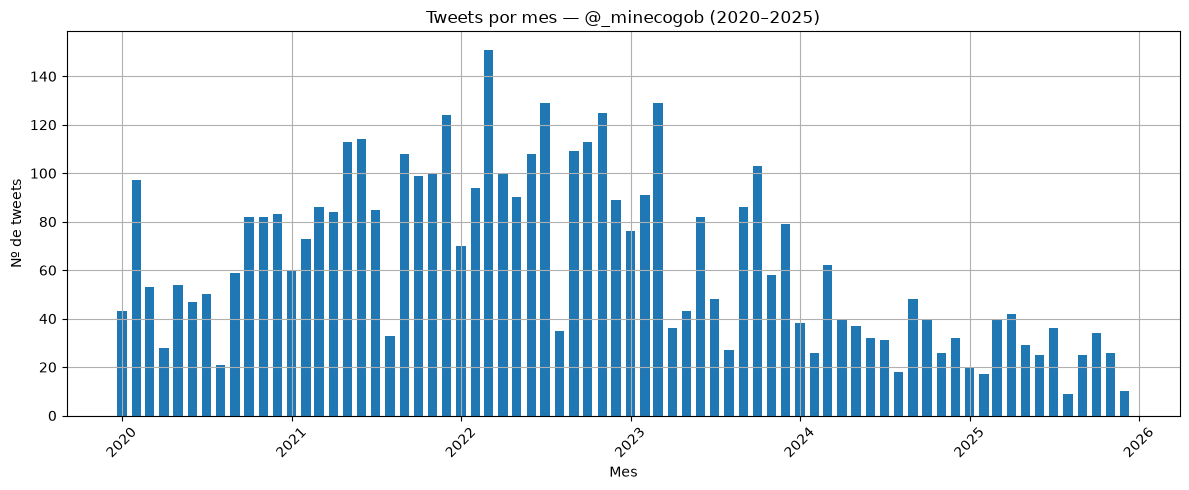

In [14]:
# ============================================================
# BLOQUE 15: Cobertura mensual de tweets
# ============================================================

# Todos los meses posibles 2020–2025
todos_los_meses = pd.date_range("2020-01-01", "2025-12-01", freq="MS")

tweets_por_mes = (
    tweets_minecocom.groupby("mes")
    .size()
    .reindex(todos_los_meses, fill_value=0)
    .rename("n_tweets")
    .reset_index()
    .rename(columns={"index": "mes"})
)

n_meses_con_datos = (tweets_por_mes["n_tweets"] > 0).sum()
n_meses_sin_datos = (tweets_por_mes["n_tweets"] == 0).sum()

print(f"Meses con al menos 1 tweet: {n_meses_con_datos} / 72")
print(f"Meses sin tweets:           {n_meses_sin_datos}")

if n_meses_sin_datos > 0:
    print("\nMeses sin tweets:")
    display(tweets_por_mes[tweets_por_mes["n_tweets"] == 0][["mes"]])

# Gráfico: tweets por mes
plt.figure()
plt.bar(tweets_por_mes["mes"], tweets_por_mes["n_tweets"], width=20)
plt.title("Tweets por mes — @_minecogob (2020–2025)")
plt.xlabel("Mes")
plt.ylabel("Nº de tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("tweets_por_mes_minecogob.png", dpi=150)
plt.show()

Observaciones ICC disponibles:  68 / 72
Meses sin dato de ICC:          4

Meses sin dato de ICC:


,mes
31,2022-08-01
43,2023-08-01
55,2024-08-01
67,2025-08-01


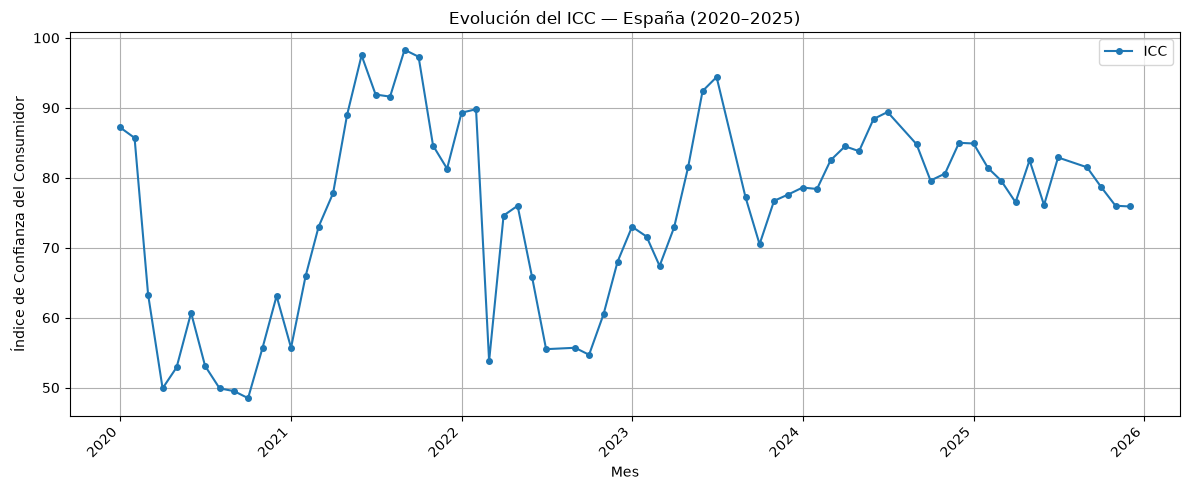

In [15]:
# ============================================================
# BLOQUE 16: Preparación del ICC 2020–2025
# ============================================================

# Reindexar sobre todos los meses posibles
icc_completo = (
    icc_periodo
    .set_index("fecha_mes")
    .reindex(todos_los_meses)
    .rename_axis("mes")
    .reset_index()
)

n_icc_disponible = icc_completo["ICC"].notna().sum()
n_icc_ausente    = icc_completo["ICC"].isna().sum()

print(f"Observaciones ICC disponibles:  {n_icc_disponible} / 72")
print(f"Meses sin dato de ICC:          {n_icc_ausente}")

if n_icc_ausente > 0:
    print("\nMeses sin dato de ICC:")
    display(icc_completo[icc_completo["ICC"].isna()][["mes"]])

# Gráfico: evolución del ICC 2020–2025
fig, ax = plt.subplots()
icc_completo.dropna(subset=["ICC"]).plot(
    x="mes", y="ICC", ax=ax, marker="o", linewidth=1.5, markersize=4
)
ax.set_title("Evolución del ICC — España (2020–2025)")
ax.set_xlabel("Mes")
ax.set_ylabel("Índice de Confianza del Consumidor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("icc_evolucion_2020_2025.png", dpi=150)
plt.show()

In [16]:
# ============================================================
# BLOQUE 17: Agregación mensual
# ============================================================

tweets_mensual = (
    tweets_minecocom
    .groupby("mes")
    .agg(
        n_tweets        = ("id",            "count"),
        comentarios_sum = ("comentarios",   "sum"),
        retweets_sum    = ("retweets",      "sum"),
        likes_sum       = ("likes",         "sum"),
        views_sum       = ("views",         "sum"),
        texto_agregado  = ("texto_limpio",  lambda x: " ".join(x.dropna()))
    )
    .reset_index()
)

# Reindexar para incluir meses sin tweets (valor 0)
tweets_mensual = (
    tweets_mensual
    .set_index("mes")
    .reindex(todos_los_meses, fill_value=0)
    .rename_axis("mes")
    .reset_index()
)
# Texto vacío donde no hay tweets
tweets_mensual["texto_agregado"] = tweets_mensual["texto_agregado"].replace(0, "")

print(f"Filas del dataset mensual de tweets: {tweets_mensual.shape[0]}")
display(tweets_mensual.head(6))

Filas del dataset mensual de tweets: 72


,mes,n_tweets,comentarios_sum,retweets_sum,likes_sum,views_sum,texto_agregado
0,2020-01-01,43,61,829,1706,0,"el negociador jefe de la ue, , se ha reunido con la vp ante la salida formal..."
1,2020-02-01,97,136,1518,3093,0,el e han firmado un acuerdo de colaboración para potenciar la competitividad...
2,2020-03-01,53,168,869,1205,0,la vicepresidenta estará esta noche en el informativo de para explicar las m...
3,2020-04-01,28,148,699,956,0,"""no hay sostenibilidad económica o financiera si no viene acompañada de sost..."
4,2020-05-01,54,286,775,1582,0,la vicepresidenta en la comisióndereconstrucción del : no tenemos que dudar ...
5,2020-06-01,47,142,994,1746,0,el gobierno autoriza ayudas por 150 m€ para la extensión de bandaancha de mu...


In [17]:
# ============================================================
# BLOQUE 18: Unión tweets mensual + ICC
# ============================================================

dataset_mensual = pd.merge(
    tweets_mensual,
    icc_completo,
    on="mes",
    how="left"
)

# Flag de disponibilidad
dataset_mensual["icc_disponible"] = dataset_mensual["ICC"].notna()
dataset_mensual["tweets_disponibles"] = dataset_mensual["n_tweets"] > 0

# Resumen de disponibilidad conjunta
n_ambos     = (dataset_mensual["icc_disponible"] & dataset_mensual["tweets_disponibles"]).sum()
n_solo_icc  = (dataset_mensual["icc_disponible"] & ~dataset_mensual["tweets_disponibles"]).sum()
n_solo_tw   = (~dataset_mensual["icc_disponible"] & dataset_mensual["tweets_disponibles"]).sum()
n_ninguno   = (~dataset_mensual["icc_disponible"] & ~dataset_mensual["tweets_disponibles"]).sum()

print("=== DISPONIBILIDAD CONJUNTA ===")
print(f"Meses con tweets E ICC disponibles:  {n_ambos}")
print(f"Meses con solo ICC (sin tweets):     {n_solo_icc}")
print(f"Meses con solo tweets (sin ICC):     {n_solo_tw}")
print(f"Meses sin ninguno de los dos:        {n_ninguno}")

print(f"\nTotal filas del dataset integrado: {dataset_mensual.shape[0]}")
display(dataset_mensual[["mes", "n_tweets", "ICC", "icc_disponible", "tweets_disponibles"]].head(12))

=== DISPONIBILIDAD CONJUNTA ===
Meses con tweets E ICC disponibles:  68
Meses con solo ICC (sin tweets):     0
Meses con solo tweets (sin ICC):     4
Meses sin ninguno de los dos:        0

Total filas del dataset integrado: 72


,mes,n_tweets,ICC,icc_disponible,tweets_disponibles
0,2020-01-01,43,87.2,True,True
1,2020-02-01,97,85.7,True,True
2,2020-03-01,53,63.3,True,True
3,2020-04-01,28,49.9,True,True
4,2020-05-01,54,52.9,True,True
5,2020-06-01,47,60.7,True,True
6,2020-07-01,50,53.1,True,True
7,2020-08-01,21,49.9,True,True
8,2020-09-01,59,49.5,True,True
9,2020-10-01,82,48.5,True,True


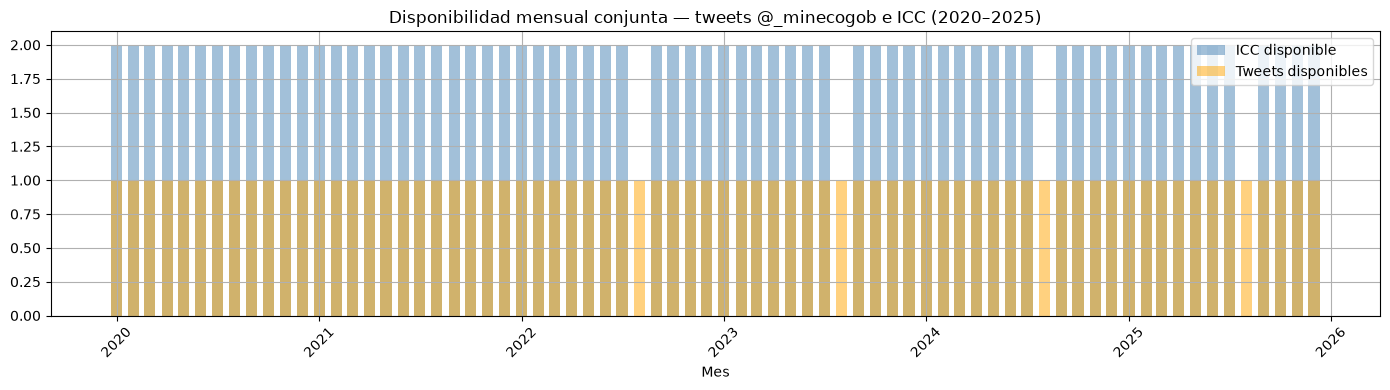

In [18]:
# Gráfico de disponibilidad conjunta
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(dataset_mensual["mes"], dataset_mensual["icc_disponible"].astype(int) * 2,
       width=20, alpha=0.5, label="ICC disponible", color="steelblue")
ax.bar(dataset_mensual["mes"], dataset_mensual["tweets_disponibles"].astype(int),
       width=20, alpha=0.5, label="Tweets disponibles", color="orange")
ax.set_title("Disponibilidad mensual conjunta — tweets @_minecogob e ICC (2020–2025)")
ax.set_xlabel("Mes")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("disponibilidad_conjunta.png", dpi=150)
plt.show()

In [19]:
# ============================================================
# BLOQUE 19: Exportación
# ============================================================

# 1. Tweets limpios @_minecogob
tweets_minecocom.to_csv("tweets_limpios_2020_2025_minecogob.csv", index=False)
print("✓ tweets_limpios_2020_2025_minecogob.csv")

# 2. Tweets complementarios @SE_Comercio
if not tweets_comercio.empty:
    tweets_comercio.to_csv("tweets_comercio_complementario_2020_2025.csv", index=False)
    print("✓ tweets_comercio_complementario_2020_2025.csv")
else:
    # Exportar DataFrame vacío con esquema
    pd.DataFrame(columns=tweets_minecocom.columns).to_csv(
        "tweets_comercio_complementario_2020_2025.csv", index=False
    )
    print("✓ tweets_comercio_complementario_2020_2025.csv (vacío — cuenta no encontrada)")

# 3. ICC limpio
icc_completo.to_csv("icc_2020_2025_limpio.csv", index=False)
print("✓ icc_2020_2025_limpio.csv")

# 4. Dataset mensual integrado
dataset_mensual.drop(columns=["texto_agregado"]).to_csv(
    "dataset_mensual_tweets_icc.csv", index=False
)
print("✓ dataset_mensual_tweets_icc.csv")

print("\n=== EXPORTACIÓN COMPLETADA ===")

✓ tweets_limpios_2020_2025_minecogob.csv
✓ tweets_comercio_complementario_2020_2025.csv
✓ icc_2020_2025_limpio.csv
✓ dataset_mensual_tweets_icc.csv

=== EXPORTACIÓN COMPLETADA ===


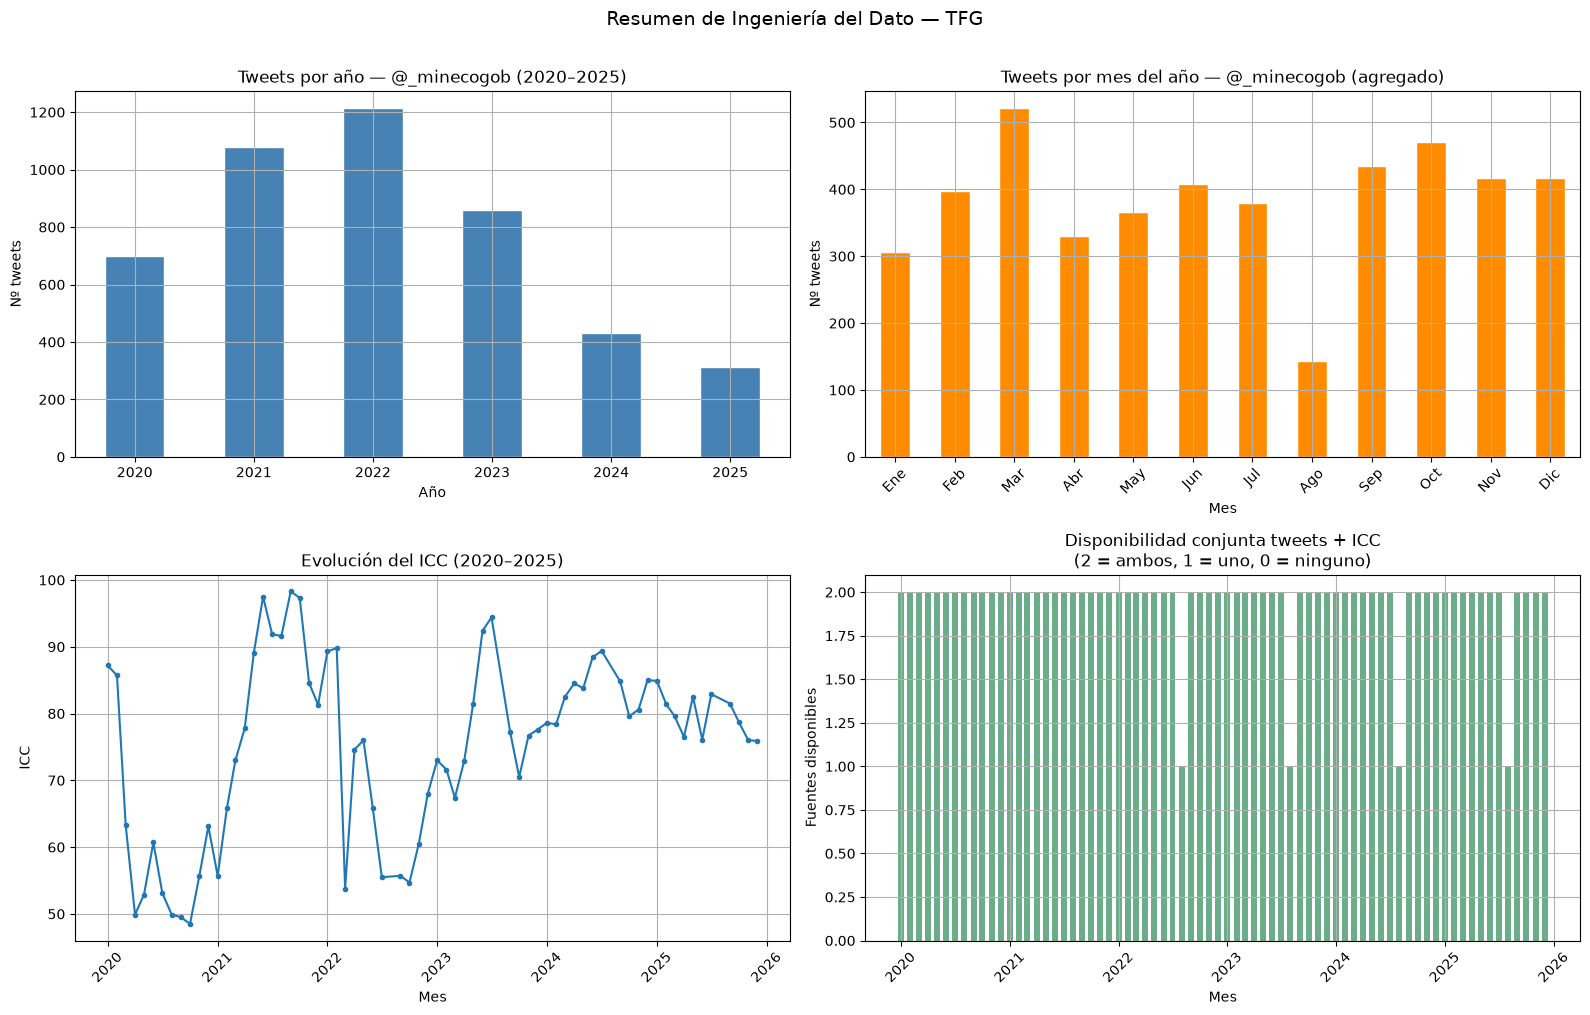


✓ Notebook de Ingeniería del Dato completado.


In [20]:
# ============================================================
# GRÁFICOS FINALES DE RESUMEN
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Tweets por año
tweets_minecocom.groupby(tweets_minecocom["fecha_dt"].dt.year).size().plot(
    kind="bar", ax=axes[0, 0], color="steelblue", edgecolor="white"
)
axes[0, 0].set_title("Tweets por año — @_minecogob (2020–2025)")
axes[0, 0].set_xlabel("Año")
axes[0, 0].set_ylabel("Nº tweets")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2. Tweets por mes del año (estacionalidad)
tweets_minecocom.groupby(tweets_minecocom["fecha_dt"].dt.month).size().plot(
    kind="bar", ax=axes[0, 1], color="darkorange", edgecolor="white"
)
axes[0, 1].set_title("Tweets por mes del año — @_minecogob (agregado)")
axes[0, 1].set_xlabel("Mes")
axes[0, 1].set_ylabel("Nº tweets")
axes[0, 1].set_xticklabels(
    ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"],
    rotation=45
)

# 3. Evolución ICC
icc_plot = icc_completo.dropna(subset=["ICC"])
axes[1, 0].plot(icc_plot["mes"], icc_plot["ICC"], marker="o", markersize=3, linewidth=1.5)
axes[1, 0].set_title("Evolución del ICC (2020–2025)")
axes[1, 0].set_xlabel("Mes")
axes[1, 0].set_ylabel("ICC")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Disponibilidad conjunta
axes[1, 1].bar(dataset_mensual["mes"],
               dataset_mensual["tweets_disponibles"].astype(int) +
               dataset_mensual["icc_disponible"].astype(int),
               width=20, color="seagreen", alpha=0.7)
axes[1, 1].set_title("Disponibilidad conjunta tweets + ICC\n(2 = ambos, 1 = uno, 0 = ninguno)")
axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Fuentes disponibles")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.suptitle("Resumen de Ingeniería del Dato — TFG", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("resumen_ingenieria_dato.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✓ Notebook de Ingeniería del Dato completado.")